In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
#from imblearn.pipeline import make_pipeline
#from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import accuracy_score, precision_recall_curve, precision_recall_fscore_support, f1_score, precision_score, recall_score, roc_auc_score, roc_curve, auc
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from joblib import dump
import numpy as np
import matplotlib.pyplot as plt
#from imblearn.under_sampling import RandomUnderSampler
import os
from osgeo import gdal
import time
import functools
import seaborn as sns
import matplotlib.ticker as ticker

In [1]:
def parse_data(file_path):
    df = pd.read_csv(file_path, delimiter=';', index_col=False)
    #print("Original dataframe", df.head())
    print("Original dataframe shape", df.shape)
    #print all column names
    print("Column names", df.columns)
    # print all the nan values in the column nbr
    print("Nan values in the column nbr", df['NBR'].isna().sum())
    # Count unique numerical IDs where 'NBR' is NaN
    if 'numerical_id' in df.columns:
        unique_ids_with_nan = df.loc[df['NBR'].isna(), 'numerical_id'].nunique()
        print("Unique numerical IDs with NaN values in 'NBR':", unique_ids_with_nan)
    else:
        print("Column 'numerical_id' not found in the dataset!")
    print("Percentage of NaN values in 'NBR':", df['NBR'].isna().sum()/df.shape[0])
    print("Number of unique numerical IDs:", df['numerical_id'].nunique())
    print("percentage of unique numerical IDs with nan values in 'NBR':", unique_ids_with_nan/df['numerical_id'].nunique())
    return df

file_path = "/home/ubuntu/work/saved_data/landsat_disturbance_detection/1D_U_Net/Data/Training/clear_forest_dataset_timesync_alltiles_landsatbands_indices3_classes_ed4_calibration.csv"
#file_path = '/home/ubuntu/work/saved_data/landsat_disturbance_detection/1D_U_Net/Data/Training/forest_dataset_timesync_alltiles_landsatbands_indices3_classes_ed2_calibration.csv'
df = parse_data(file_path)

NameError: name 'pd' is not defined

In [ ]:
def encoding_disturbances(df):

    #df['class'] = df['class_level2'].apply(lambda x: 1 if x == 'disturbance' else 0)
    df['class'] = df['new_class2']
    #np.where(df['class_level2'] == 'stand-replacing disturbance', 1, 0)

    # check for the first disturbance id 
    first_id = df.loc[df['class'] == 1, 'fid'].iloc[0]
    print("First ID with disturbance:", first_id)


    return df

df = encoding_disturbances(df)
print("Shape after encoding disturbances", df.shape)
#print(df.head)

First ID with disturbance: 126
Shape after encoding disturbances (567084, 27)


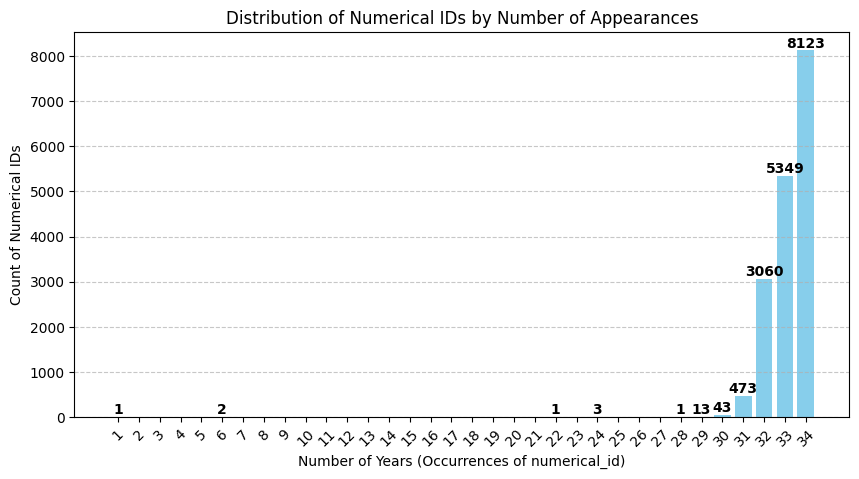

In [ ]:
# Count occurrences of each numerical_id
id_counts = df['numerical_id'].value_counts()

# Count how many numerical_id's appear a certain number of times
count_distribution = id_counts.value_counts().sort_index()

# Filter only counts from 1 to 34
count_distribution = count_distribution[count_distribution.index]

# Plot bar chart
plt.figure(figsize=(10, 5))
bars = plt.bar(count_distribution.index, count_distribution.values, color='skyblue')

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, str(height), ha='center', va='bottom', fontsize=10, fontweight='bold')

# Labels and title
plt.xlabel('Number of Years (Occurrences of numerical_id)')
plt.ylabel('Count of Numerical IDs')
plt.title('Distribution of Numerical IDs by Number of Appearances')
plt.xticks(range(1, 35), rotation=45)  # Show all years from 1 to 34
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.show()

In [ ]:
def drop_columns(df):
    df = df[['year', 'numerical_id', 'class', 'NDVI', 'NBR']]
    return df 

df = drop_columns(df)
print("Shape after dropping columns", df.shape)
print(df.head)

Shape after dropping columns (567084, 5)
<bound method NDFrame.head of         year  numerical_id  class      NDVI       NBR
0       1985             1      0  0.903261  0.691500
1       1986             1      0  0.846658  0.697250
2       1987             1      0  0.884108  0.714342
3       1988             1      0  0.862136  0.678677
4       1989             1      0  0.855061  0.706518
...      ...           ...    ...       ...       ...
567079  2014         19818      0  0.845379  0.790024
567080  2015         19818      0  0.789429  0.693477
567081  2016         19818      0       NaN       NaN
567082  2017         19818      0       NaN       NaN
567083  2018         19818      0  0.825513  0.720802

[567084 rows x 5 columns]>


In [ ]:
def count_numerical_ids(df):
    id_counts = df['numerical_id'].value_counts()

    # Count occurrences of each numerical_id
    id_counts = df['numerical_id'].value_counts()
    # Filter numerical_id's that appear less than 34 times
    num_ids_less_than_34 = (id_counts < 34).sum()

    print(f"Number of numerical_id's that appear in less than 34 years: {num_ids_less_than_34}")
    return id_counts

print(count_numerical_ids(df))

Number of numerical_id's that appear in less than 34 years: 8946
numerical_id
1        34
10706    34
10729    34
10730    34
10731    34
         ..
9579     24
6243     22
3010      6
1771      6
13028     1
Name: count, Length: 17069, dtype: int64


In [ ]:
def clear_folder(folder_path):
    """Remove all files inside the folder but keep the folder itself."""
    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)
        if os.path.isfile(file_path):
            os.remove(file_path)  # Remove only files, not the folder itself
    return 0

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

def plot_time_series(df, output_folder, time_column, value_columns, id_column):
    """
    Plots time series for each numerical_id with multiple value columns, 
    highlights the years when class == 1, and optionally shows interpolated values.

    Parameters:
    df (DataFrame): Input dataset.
    output_folder (str): Folder to save the plots.
    time_column (str): Column representing time (e.g., 'year').
    value_columns (list): List of value columns to plot (e.g., ['NBR', 'NDVI']).
    id_column (str): Column representing unique IDs (e.g., 'numerical_id').
    """
    
    # Debugging: Print current directory and output folder path
    print("Current working directory:", os.getcwd())
    print("Output folder path:", output_folder)
    
    # Make sure we are using an absolute path
    output_folder = os.path.abspath(output_folder)
    print("Resolved output folder:", output_folder)
    
    # Ensure the output folder exists
    os.makedirs(output_folder, exist_ok=True)
    
    # Clean up old plots (if necessary)
    for file in os.listdir(output_folder):
        file_path = os.path.join(output_folder, file)
        if os.path.isfile(file_path):
            os.remove(file_path)  # Remove each file
    
    # Use seaborn style defaults
    sns.set_theme(rc={'figure.figsize': (11, 4)})

    # Convert year column to integers (if not already)
    df[time_column] = df[time_column].astype(int)

    # Group by numerical_id
    grouped = df.groupby(id_column)

    # Iterate over each group and plot the time series
    for num_id, group in grouped:
        plt.figure(figsize=(10, 5))

        # Plot each value column with a different color
        for col in value_columns:
            plt.plot(group[time_column], group[col], marker='o', linestyle='-', label=col)

        # Highlight the years where class == 1 (red dots) - disturbance
        class_1_years = group[group['class'] == 1]
        plt.scatter(class_1_years[time_column], class_1_years[value_columns[0]], 
                    color='red', label='Disturbance', zorder=5)

        # If 'interpolated' column exists, mark interpolated values with green dots
        interpolated_years = None
        if 'interpolated' in group.columns:
            interpolated_years = group[group['interpolated']]
            plt.scatter(interpolated_years[time_column], interpolated_years[value_columns[0]],
                        color='black', marker='x', label='Interpolated', zorder=8, s=100)  

        # Set x-axis labels as years
        plt.xticks(group[time_column], labels=group[time_column].astype(str))
        plt.xlabel('Year')
        plt.ylabel('Value') 
        plt.title(f'Time Series for ID: {num_id}')
        plt.legend()
        plt.grid()

        # Ensure x-axis shows only whole years
        plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

        # Determine the prefix for the plot name based on disturbance or interpolation
        plot_prefix = ""
        
        # Check if there is a disturbance (class == 1)
        if not class_1_years.empty:
            plot_prefix += "D_"  # Add 'D' if disturbance is present
        
        # Check if there are interpolated values
        if interpolated_years is not None and not interpolated_years.empty:
            plot_prefix += "I_"  # Add 'I' if interpolated values are present

        # Save the plot with the appropriate name
        plot_filename = f"{plot_prefix}{num_id}.png"
        plot_path = os.path.join(output_folder, plot_filename)
        plt.savefig(plot_path)
        plt.close()  # Free memory

    print(f"Time series plots saved in: {output_folder}")

# Example usage
#output_folder = "/home/ubuntu/work/saved_data/landsat_disturbance_detection/1D_U_Net/clean_notebooks/time_series_plots"
#plot_time_series(df, output_folder, time_column="year", value_columns=["NBR", "NDVI"], id_column="numerical_id")


In [ ]:
# delete all time series where the length is under 30

def filter_numerical_ids(df, min_count=30):
    """
    Remove numerical_id entries that appear less than min_count times.
    """
    id_counts = df['numerical_id'].value_counts()
    
    # Get the IDs that meet the minimum count requirement
    valid_ids = id_counts[id_counts >= min_count].index

    # Filter the DataFrame
    filtered_df = df[df['numerical_id'].isin(valid_ids)]
    
    return filtered_df

# Apply filtering
df_filtered = filter_numerical_ids(df, min_count=30)

# Print the count after filtering
print(count_numerical_ids(df_filtered))

Number of numerical_id's that appear in less than 34 years: 8925
numerical_id
1        34
10796    34
10733    34
10734    34
10438    34
         ..
445      30
754      30
755      30
1336     30
19209    30
Name: count, Length: 17048, dtype: int64


In [ ]:
# mark all all the nan values for later plotting
df_filtered['interpolated'] = df_filtered['NBR'].isna()

print(df_filtered.head())

   year  numerical_id  class      NDVI       NBR  interpolated
0  1985             1      0  0.903261  0.691500         False
1  1986             1      0  0.846658  0.697250         False
2  1987             1      0  0.884108  0.714342         False
3  1988             1      0  0.862136  0.678677         False
4  1989             1      0  0.855061  0.706518         False


/tmp/ipykernel_384082/2998175777.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['interpolated'] = df_filtered['NBR'].isna()


In [ ]:
# apply forward fill in pandas

df_filled = df_filtered.ffill()
print(df_filled)

output_folder = "landsat_disturbance_detection/1D_U_Net/clean_notebooks/ffill"
plot_time_series(df_filled, output_folder, time_column="year", value_columns=["NBR", "NDVI"], id_column="numerical_id")

        year  numerical_id  class      NDVI       NBR  interpolated
0       1985             1      0  0.903261  0.691500         False
1       1986             1      0  0.846658  0.697250         False
2       1987             1      0  0.884108  0.714342         False
3       1988             1      0  0.862136  0.678677         False
4       1989             1      0  0.855061  0.706518         False
...      ...           ...    ...       ...       ...           ...
567079  2014         19818      0  0.845379  0.790024         False
567080  2015         19818      0  0.789429  0.693477         False
567081  2016         19818      0  0.789429  0.693477          True
567082  2017         19818      0  0.789429  0.693477          True
567083  2018         19818      0  0.825513  0.720802         False

[566572 rows x 6 columns]
Current working directory: /home/ubuntu/work/saved_data/landsat_disturbance_detection/1D_U_Net/clean_notebooks
Output folder path: landsat_disturbance_detect

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fe52030e180>>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


Time series plots saved in: /home/ubuntu/work/saved_data/landsat_disturbance_detection/1D_U_Net/clean_notebooks/landsat_disturbance_detection/1D_U_Net/clean_notebooks/ffill


In [ ]:
# instead, apply linear interpolation now 

df_linear = df_filtered.interpolate()
print(df_linear)

        year  numerical_id  class      NDVI       NBR  interpolated
0       1985             1      0  0.903261  0.691500         False
1       1986             1      0  0.846658  0.697250         False
2       1987             1      0  0.884108  0.714342         False
3       1988             1      0  0.862136  0.678677         False
4       1989             1      0  0.855061  0.706518         False
...      ...           ...    ...       ...       ...           ...
567079  2014         19818      0  0.845379  0.790024         False
567080  2015         19818      0  0.789429  0.693477         False
567081  2016         19818      0  0.801457  0.702585          True
567082  2017         19818      0  0.813485  0.711694          True
567083  2018         19818      0  0.825513  0.720802         False

[566572 rows x 6 columns]


Current working directory: /home/ubuntu/work/saved_data/landsat_disturbance_detection/1D_U_Net/clean_notebooks
Output folder path: landsat_disturbance_detection/1D_U_Net/clean_notebooks/linear_interpolation
Resolved output folder: /home/ubuntu/work/saved_data/landsat_disturbance_detection/1D_U_Net/clean_notebooks/landsat_disturbance_detection/1D_U_Net/clean_notebooks/linear_interpolation


KeyboardInterrupt: 

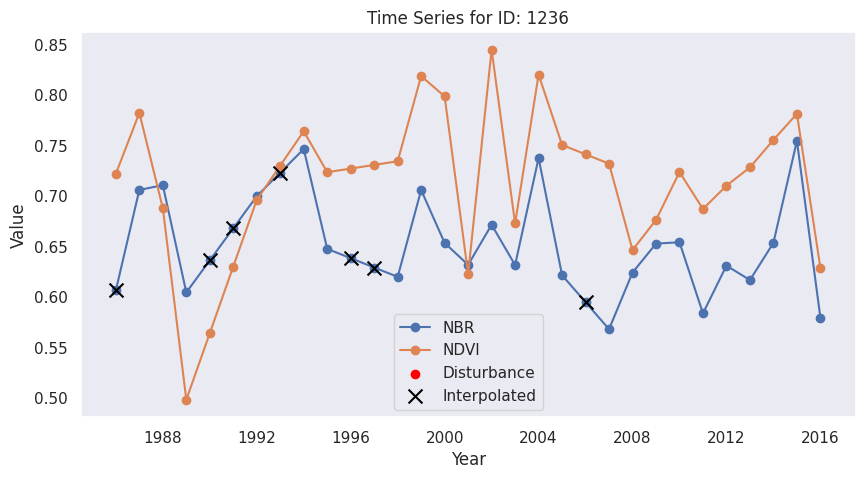

In [ ]:
output_folder = "landsat_disturbance_detection/1D_U_Net/clean_notebooks/linear_interpolation"
plot_time_series(df_linear, output_folder, time_column="year", value_columns=["NBR", "NDVI"], id_column="numerical_id")

In [ ]:
#apply polynomial interpolation

df_quadratic = df_filtered.interpolate(method = 'polynomial', order= 2)
print(df_quadratic)

        year  numerical_id  class      NDVI       NBR  interpolated
0       1985             1      0  0.903261  0.691500         False
1       1986             1      0  0.846658  0.697250         False
2       1987             1      0  0.884108  0.714342         False
3       1988             1      0  0.862136  0.678677         False
4       1989             1      0  0.855061  0.706518         False
...      ...           ...    ...       ...       ...           ...
567079  2014         19818      0  0.845379  0.790024         False
567080  2015         19818      0  0.789429  0.693477         False
567081  2016         19818      0  0.760366  0.638531          True
567082  2017         19818      0  0.772394  0.647639          True
567083  2018         19818      0  0.825513  0.720802         False

[566572 rows x 6 columns]


/tmp/ipykernel_6110/448920583.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["year"] = df["year"].astype(int)
/tmp/ipykernel_6110/448920583.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["year"] = df["year"].astype(int)
/tmp/ipykernel_6110/448920583.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_

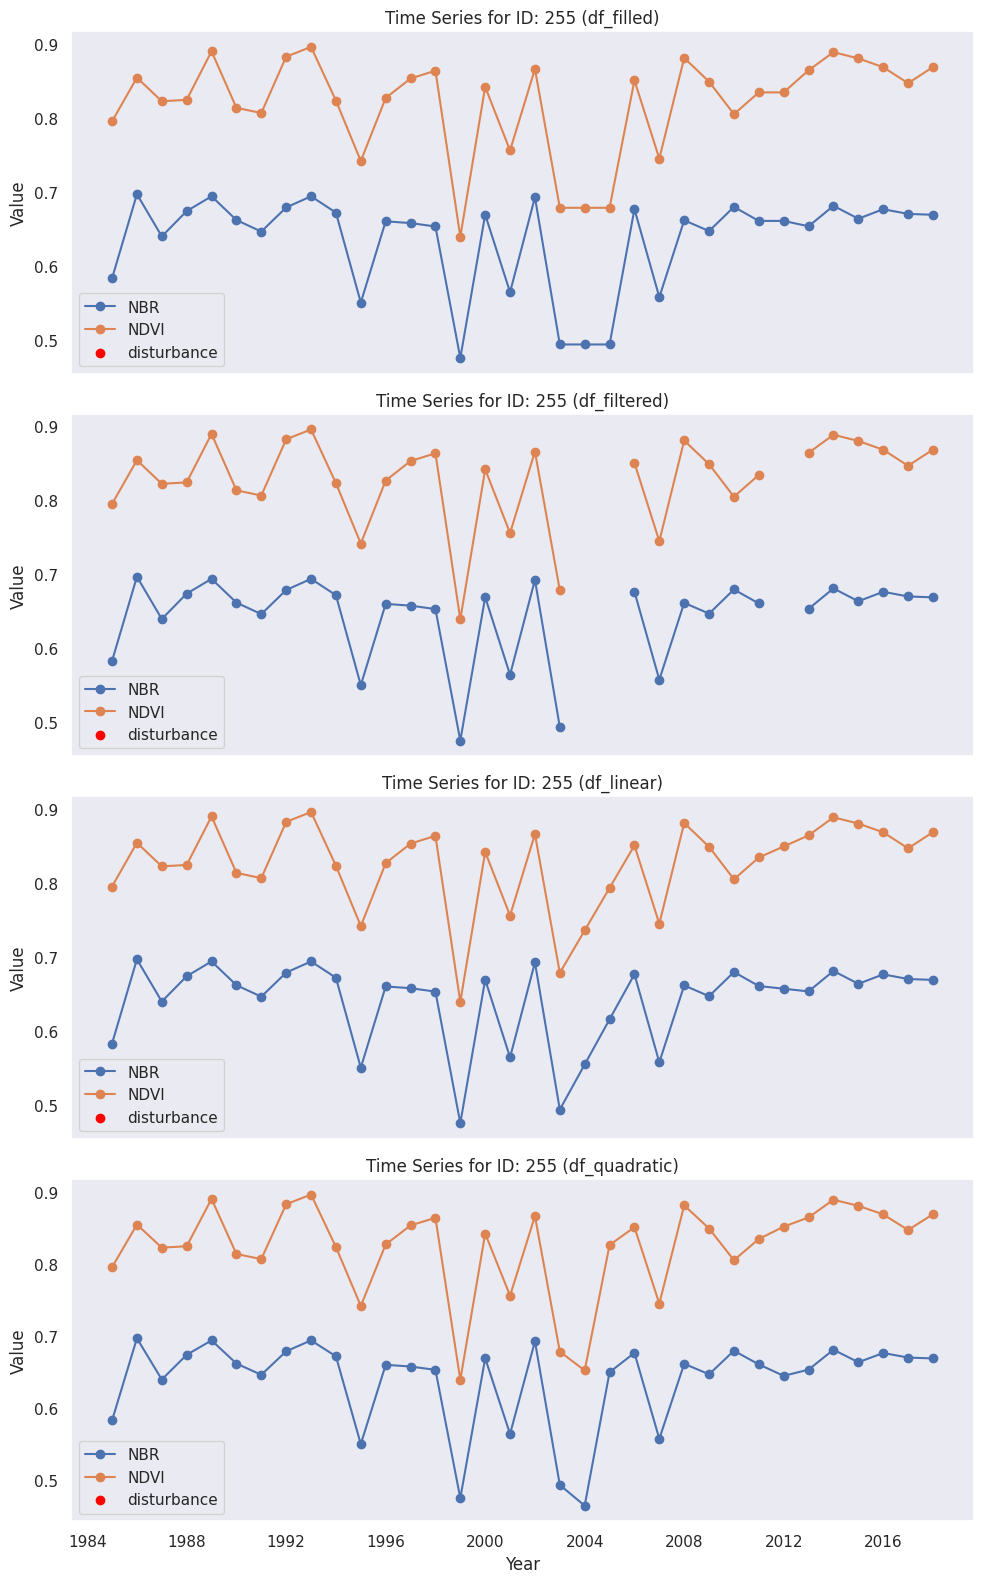

In [ ]:
# Define the value columns
value_columns = ["NBR", "NDVI"]

# Filter data for numerical_id = 255 from all dataframes
df_255 = df_filled[df_filled['numerical_id'] == 255]
df_filtered_255 = df_filtered[df_filtered['numerical_id'] == 255]
df_linear_255 = df_linear[df_linear['numerical_id'] == 255]
df_quadratic_255 = df_quadratic[df_quadratic['numerical_id'] == 255]

# Check if any of the dataframes are empty
if df_255.empty:
    print("No data found for ID 255 in df_filled.")
if df_filtered_255.empty:
    print("No data found for ID 255 in df_filtered.")
if df_linear_255.empty:
    print("No data found for ID 255 in df_linear.")
if df_quadratic_255.empty:
    print("No data found for ID 255 in df_quadratic.")

# Use seaborn style defaults
sns.set_theme(rc={'figure.figsize': (11, 16)})  # Increased height to fit four plots

# Convert year column to integers (if not already)
for df in [df_255, df_filtered_255, df_linear_255, df_quadratic_255]:
    df["year"] = df["year"].astype(int)

# Create figure with 4 subplots (4 rows, 1 column)
fig, axes = plt.subplots(4, 1, figsize=(10, 16), sharex=True)

# Function to plot each dataframe
def plot_df(ax, df, title):
    for col in value_columns:
        ax.plot(df["year"], df[col], marker='o', linestyle='-', label=col)
    
    # Highlight the years where class == 1
    class_1_years = df[df['class'] == 1]
    ax.scatter(class_1_years["year"], class_1_years[value_columns[0]], color='red', label='disturbance', zorder=5)

    ax.set_ylabel('Value')
    ax.set_title(title)
    ax.legend()
    ax.grid()

# Plot for each dataframe
plot_df(axes[0], df_255, "Time Series for ID: 255 (df_filled)")
plot_df(axes[1], df_filtered_255, "Time Series for ID: 255 (df_filtered)")
plot_df(axes[2], df_linear_255, "Time Series for ID: 255 (df_linear)")
plot_df(axes[3], df_quadratic_255, "Time Series for ID: 255 (df_quadratic)")

# Set x-axis labels for the last subplot only
axes[3].set_xlabel('Year')

# Ensure x-axis only shows whole years
axes[3].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Show the plots
plt.tight_layout()
plt.show()

In [ ]:
# Group by 'numerical_id' and sort within each group
df_grouped = df.groupby('numerical_id', group_keys=False)         #.apply(lambda x: x.sort_values('year')).reset_index(drop=True)
print(df_grouped.head())

        year  numerical_id  class      NDVI       NBR
0       1985             1      0  0.903261  0.691500
1       1986             1      0  0.846658  0.697250
2       1987             1      0  0.884108  0.714342
3       1988             1      0  0.862136  0.678677
4       1989             1      0  0.855061  0.706518
...      ...           ...    ...       ...       ...
567052  1985         19818      0       NaN       NaN
567053  1986         19818      0  0.731972  0.670902
567054  1988         19818      0       NaN       NaN
567055  1989         19818      0  0.745163  0.657218
567056  1990         19818      0       NaN       NaN

[85341 rows x 5 columns]


In [ ]:
# now sort for the years in each group
#df_sorted = df_grouped.apply(lambda x: x.sort_values('year')).reset_index(drop=True)
df_sorted = df_grouped.apply(lambda x: x.sort_values('year')).reset_index(drop=True)
print(df_sorted.head(60))

    year  numerical_id  class      NDVI       NBR
0   1985             1      0  0.903261  0.691500
1   1986             1      0  0.846658  0.697250
2   1987             1      0  0.884108  0.714342
3   1988             1      0  0.862136  0.678677
4   1989             1      0  0.855061  0.706518
5   1990             1      0  0.808742  0.670267
6   1991             1      0  0.893613  0.683797
7   1992             1      0  0.882402  0.719419
8   1993             1      0  0.895533  0.703258
9   1994             1      0  0.845774  0.699545
10  1995             1      0  0.876190  0.754110
11  1996             1      0  0.853152  0.731570
12  1997             1      0  0.904382  0.687691
13  1998             1      0  0.910240  0.697420
14  1999             1      0  0.839717  0.680603
15  2000             1      0  0.881148  0.701621
16  2001             1      0  0.912955  0.709771
17  2002             1      0  0.920823  0.735578
18  2003             1      0  0.904957  0.704099


/tmp/ipykernel_367637/2914359665.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sorted = df_grouped.apply(lambda x: x.sort_values('year')).reset_index(drop=True)


In [ ]:
# notebooks: (1) Plotten, (2) Konvertieren, (3) Trainieren
# 30 Jahre extrahieren --> plotten  (Feature extraction)
# Eingangsmatrix für RF plotten (nxd) --> als csv speichern
# neue csv für RF laden

# Group by 'numerical_id' and sort within each group
df_grouped = df_linear.sort_values(by=["numerical_id", "year"])  # Corrected line
# see the documentation that this works: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html

# Calculate the differences between the current row and the previous row

df_grouped['NDVI_diff'] = df_grouped.groupby('numerical_id')['NDVI'].diff() # backward difference
df_grouped['NBR_diff'] = df_grouped.groupby('numerical_id')['NBR'].diff() # backward difference      ### check?!

print(df_filtered.head())
df_filtered = df_grouped.dropna()

df_filtered = df_filtered.drop('interpolated', axis=1)

print(df_filtered.head())

print(df_filtered['class'].value_counts())

# Split the DataFrame based on 'numerical_id', ensuring the split is done by group

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df_filtered[['NDVI', 'NDVI_diff', 'NBR', 'NBR_diff']], 
                                                    df_filtered['class'], 
                                                    test_size=0.2, 
                                                    stratify=df_filtered['class'], ### check ?!
                                                    random_state=42)

# Print the resulting train and test datasets
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

#X_train = df_filtered[['NDVI', 'NDVI_diff', 'NBR', 'NBR_diff']].values
#y_train = df_filtered[['class']].astype(int)

#X_test = df_filtered[['NDVI', 'NDVI_diff', 'NBR', 'NBR_diff']].values
#y_test = df_filtered[['class']].astype(int)

# %% [markdown]
# Train the model and save it. 

# %%
print(X_train.shape)
print(y_train.shape)

# Flatten y_train and y_test to 1D
#y_train = y_train.ravel()
#y_test = y_test.ravel()



   year  numerical_id  class      NDVI       NBR  NDVI_diff  NBR_diff
1  1986             1      0  0.846658  0.697250  -0.056603  0.005750
2  1987             1      0  0.884108  0.714342   0.037450  0.017092
3  1988             1      0  0.862136  0.678677  -0.021973 -0.035665
4  1989             1      0  0.855061  0.706518  -0.007075  0.027841
5  1990             1      0  0.808742  0.670267  -0.046319 -0.036251
   year  numerical_id  class      NDVI       NBR  NDVI_diff  NBR_diff
1  1986             1      0  0.846658  0.697250  -0.056603  0.005750
2  1987             1      0  0.884108  0.714342   0.037450  0.017092
3  1988             1      0  0.862136  0.678677  -0.021973 -0.035665
4  1989             1      0  0.855061  0.706518  -0.007075  0.027841
5  1990             1      0  0.808742  0.670267  -0.046319 -0.036251
class
0    547047
1      2477
Name: count, dtype: int64
X_train shape: (439619, 4)
y_train shape: (439619,)
X_test shape: (109905, 4)
y_test shape: (109905,)
(4

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import joblib

y_train = y_train.squeeze()             ### check ?!
y_test = y_test.squeeze()

model = RandomForestClassifier(n_estimators=25, max_depth=7, max_features=None, random_state=0)
model.fit(X_train,y_train)

RandomForestClassifier(max_depth=5, max_features=None, n_estimators=25,
                       random_state=0)

In [ ]:
# Use the test data to evaluate predictions.

# %%
preds = model.predict(X_test)
from sklearn.metrics import f1_score

print(y_test.shape)
print(preds.shape)

# Compute overall accuracy
accuracy = accuracy_score(y_test, preds)
print(f"Accuracy: {accuracy:.4f}")

print(y_test.shape)
print(preds.shape)

# Generate a detailed classification report (includes precision, recall, F1-score for each class)
report = classification_report(y_test, preds, target_names=["Class 0", "Class 1"])
print(report)

(109905,)
(109905,)
Accuracy: 0.9957
(109905,)
(109905,)
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00    109410
     Class 1       0.55      0.18      0.27       495

    accuracy                           1.00    109905
   macro avg       0.77      0.59      0.63    109905
weighted avg       0.99      1.00      0.99    109905



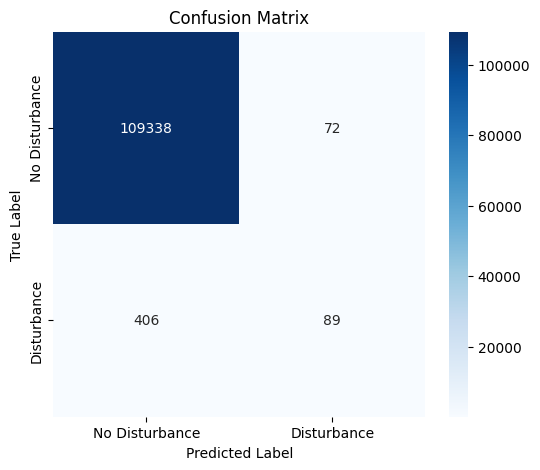

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(y_test, preds)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=["No Disturbance", "Disturbance"], yticklabels=["No Disturbance", "Disturbance"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()